In [1]:
import sys
import os
import pandas as pd 

#use this when run into notebook
sys.path.append(os.path.abspath(".."))

from src.data import DataLoader
from src.sql_utils import sqlData

In [2]:
loader_sql = sqlData()
cost_and_demand, wh_data = loader_sql.load_sql_data()
df = pd.merge(cost_and_demand,wh_data[['warehouse','current_supply_unit']],how='left', on='warehouse')
df

,warehouse,Jakarta,Bekasi,Bogor,Depok,Tangerang,Serang,Bandung,Cirebon,Semarang,Solo,Yogyakarta,Surabaya,Malang,Kediri,Jember,current_supply_unit
0,WH-A,7180.0,16764.0,33393.0,19645.0,18378.0,53279.0,82383.0,135525.0,269581.0,309407.0,284761.0,438252.0,441503.0,396861.0,519123.0,210000.0
1,WH-B,267408.0,257820.0,265052.0,268476.0,282900.0,317677.0,205977.0,139997.0,5000.0,57652.0,64689.0,173998.0,179487.0,136209.0,255996.0,145000.0
2,WH-C,436086.0,426506.0,434012.0,437444.0,451603.0,486444.0,374400.0,308995.0,173998.0,145208.0,180245.0,5000.0,56690.0,72649.0,99606.0,120000.0
3,Demand,5886.0,2581.0,2242.0,2304.0,2450.0,1509.0,5906.0,1911.0,4535.0,3428.0,3907.0,5807.0,3177.0,1448.0,1757.0,NaN


In [3]:
from src.optimization import CostTransportation

loader = CostTransportation(df, wh_data)
status, minimum_cost, result_df_opt1 = loader.optimization()

In [4]:
from src.sensitivity_cost import SensitivityCost

loader = SensitivityCost(df, wh_data, minimum_cost, min_qty = 200)
status_sensitivity, adjustment_cost, percentage, result_df_opt2 = loader.optimization()

##Data Visualization

### Comparison Distribution of QTY based on route 

In [5]:
result_df_opt1.pivot(index='warehouse', columns='city', values='qty')

city,Bandung,Bekasi,Bogor,Cirebon,Depok,Jakarta,Jember,Kediri,Malang,Semarang,Serang,Solo,Surabaya,Tangerang,Yogyakarta
warehouse,,,,,,,,,,,,,,,
WH-A,5906.0,2581.0,2242.0,1911.0,2304.0,5886.0,0.0,0.0,0.0,0.0,1509.0,0.0,0.0,2450.0,0.0
WH-B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4535.0,0.0,3428.0,0.0,0.0,3907.0
WH-C,0.0,0.0,0.0,0.0,0.0,0.0,1757.0,1448.0,3177.0,0.0,0.0,0.0,5807.0,0.0,0.0


In [6]:
result_df_opt2.pivot(index='warehouse', columns='city', values='qty')

city,Bandung,Bekasi,Bogor,Cirebon,Depok,Jakarta,Jember,Kediri,Malang,Semarang,Serang,Solo,Surabaya,Tangerang,Yogyakarta
warehouse,,,,,,,,,,,,,,,
WH-A,5506.0,2181.0,1842.0,1511.0,1904.0,5486.0,200.0,200.0,200.0,200.0,1109.0,200.0,200.0,2050.0,200.0
WH-B,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,4135.0,200.0,3028.0,200.0,200.0,3507.0
WH-C,200.0,200.0,200.0,200.0,200.0,200.0,1357.0,1048.0,2777.0,200.0,200.0,200.0,5407.0,200.0,200.0


## Notes

### WH-A : Jakarta
### WH-B : Semarang
### WH-C : Surabaya

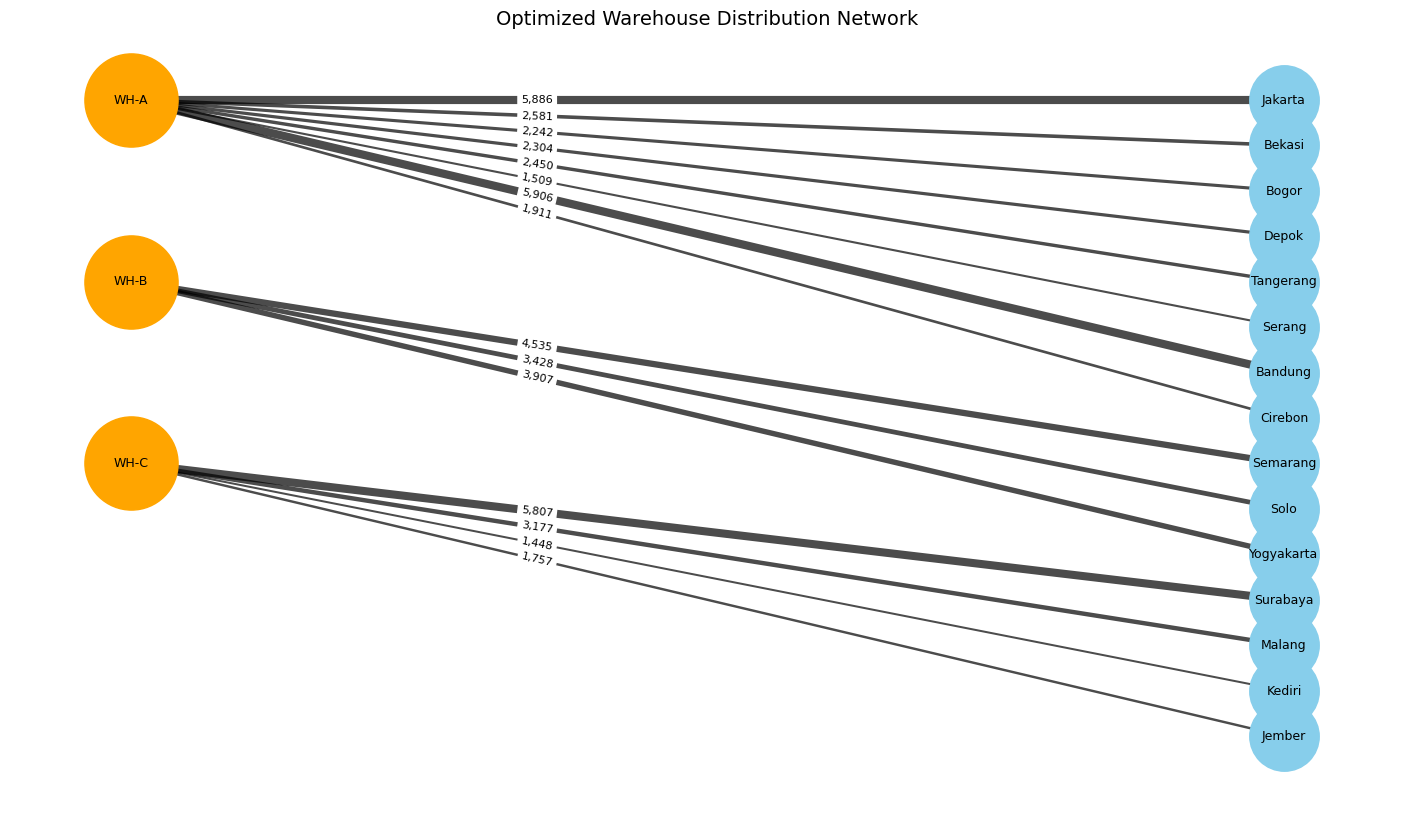

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

result_df_top15 =result_df_opt1[result_df_opt1['qty']>0]

G=nx.Graph()

for _,r in result_df_top15.iterrows():
    G.add_edge(
        f"{r['warehouse']}",
        r['city'],
        weight=int(r['qty'])
    )

plt.figure(figsize=(18,10))

warehouse_nodes=[n for n in G.nodes() if "WH" in n]

city_nodes=[n for n in G.nodes() if "WH" not in n]

weights = nx.get_edge_attributes(G, 'weight')

edge_widths = [ v / 1000 for v in weights.values()
]

#  set manual position
pos={}

for i,node in enumerate(warehouse_nodes):
    pos[node]=(0,-i*4)

for i,node in enumerate(city_nodes):
    pos[node]=(8,-i)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=warehouse_nodes,
    node_size=4500,
    node_color='orange'
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=city_nodes,
    node_size=2500,
    node_color='skyblue'
)

nx.draw_networkx_edges(
    G,
    pos,
    width= edge_widths,
    alpha = 0.7
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)

edge_labels={(k1,k2):f"{v:,.0f}" for (k1,k2),v in 
    nx.get_edge_attributes(
    G,
    'weight'
    ).items()
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.35
)

plt.axis("off")

plt.title("Optimized Warehouse Distribution Network", fontsize=14)

plt.show()

In [7]:
import plotly.graph_objects as go

wh_loc={

'WH-A':(-6.2088,106.8456),
'WH-B':(-6.966,110.4166),
'WH-C':(-7.2575,112.7521)

}

city_loc = {
 "Jakarta": (-6.2088, 106.8456),
 "Bekasi": (-6.2383, 106.9756),
 "Bogor": (-6.5950, 106.8166),
 "Depok": (-6.4025, 106.7942),
 "Tangerang": (-6.1783, 106.6319),
 "Bandung": (-6.9175, 107.6191),
 "Cirebon": (-6.7320, 108.5523),
 "Semarang": (-6.9666, 110.4166),
 "Solo": (-7.5755, 110.8243),
 "Yogyakarta": (-7.7956, 110.3695),
 "Surabaya": (-7.2575, 112.7521),
 "Malang": (-7.9666, 112.6326),
 "Kediri": (-7.8480, 112.0178),
 "Jember": (-8.1724, 113.7005),
 "Serang": (-6.1200, 106.1503)
}

fig=go.Figure()

# warehouse
for w,(lat,lon) in wh_loc.items():
    fig.add_trace(
        go.Scattergeo(
            lon=[lon],
            lat=[lat],
            mode='markers+text',
            text=[f"{w}"],
            textposition='top center',
            marker=dict(
                size=18
            ),
            name=w
        )

    )

# city marker
for c,(lat,lon) in city_loc.items():
    fig.add_trace(
        go.Scattergeo(
            lon=[lon],
            lat=[lat],
            mode='markers+text',
            hovertext=c,
            text=[c],
            textposition='bottom center',
            marker=dict(
                size=8
            ),
            showlegend=False
        )
    )

# route
for _,r in result_df_opt1.iterrows():
    w=r['warehouse']
    c=r['city']
    lat1,lon1=wh_loc[w]
    lat2,lon2=city_loc[c]
    fig.add_trace(
        go.Scattergeo(
            lon=[lon1,lon2],
            lat=[lat1,lat2],
            mode='lines',
            hovertext=
            f"{w} → {c}<br>Qty:{r['qty']:,.0f}",
            line=dict(
                width=2
            ),
            showlegend=False
        )
    )

fig.update_layout(

title=
"Optimized Distribution Network",
geo=dict(
    #scope='asia',
    center=dict(
        lat=-7,
        lon=110
    ),
    projection_scale=8
),
height=600
)
fig.show()